# configaration

In [ ]:
url="put_your_dataset_url_here"

In [ ]:
project_path = r"put_your_project_path_here"


In [ ]:
import sys
import json
import os
import subprocess
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.append(os.path.abspath('..'))
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import huggingface_hub
huggingface_hub.login('put_your_huggingface_token_here') 

def load_and_print_results(file_path):
    if os.path.exists(file_path):
        with open(file_path) as f:
            for line in f:
                try:
                    data = json.loads(line)
                    print(data)
                except json.JSONDecodeError as e:
                    print(f"Error decoding JSON: {e}")
    else:
        print(f"No results found at {file_path}")


import subprocess
import sys
import os



import subprocess
import sys
import os

def run_command(command):
    current_python = sys.executable
    windows_command = command.replace("python3", f'"{current_python}"')
    
    current_env = os.environ.copy()
    
    process = subprocess.Popen(
        windows_command, 
        shell=True, 
        stdout=subprocess.PIPE, 
        stderr=subprocess.STDOUT, 
        text=True, 
        encoding="utf-8",
        bufsize=1,
        env=current_env 
    )
    
    for line in process.stdout:
        print(line, end="")
        sys.stdout.flush() 
        
    process.wait()

# for working with GPU

In [2]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 --force-reinstall

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp311-cp311-win_amd64.whl (2449.4 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp311-cp311-win_amd64.whl (6.1 MB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached https://download.pytorc

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.8.5 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import torch
import sys

print(f"Python Version: {sys.version}")
print(f"PyTorch Version: {torch.__version__}")
print(f"Is CUDA available?: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected by PyTorch.")

Python Version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
PyTorch Version: 2.5.1+cu121
Is CUDA available?: True
GPU Device Name: NVIDIA GeForce RTX 4060 Ti


# Zero-shot cross-modal retrieval

In [7]:
command = (
    'set PYTHONPATH=..&& '
    'python3 -m clip_benchmark.cli eval --pretrained_model muskModel.txt '
    '--dataset pathmmu_retrieval '
    '--task zeroshot_retrieval '
    '--batch_size 8 '
    '--num_workers 4 '
    '--seed 42 '
    '--recall_k 1 10 50 '
    f'--dataset_root "{url}" '
    '--output ./results/benchmark_musk_retrieval.json'
)
run_command(command)

Models: [['musk_large_patch16_384', 'hf_hub:xiangjx/musk']]
Datasets: ['pathmmu_retrieval']
Languages: ['en']
Running 'zeroshot_retrieval' on 'pathmmu_retrieval' with the model 'hf_hub:xiangjx/musk' on language 'en'
Load ckpt from hf_hub:xiangjx/musk
Dataset size: 7774
Dataset split: test
c:\Users\97250\Desktop\שנה ג\סמסטר ב\אונקולוגיה\הדגמה 1\MUSK\benchmarks\clip_benchmark\metrics\zeroshot_retrieval.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():

0it [00:00, ?it/s]c:\Users\97250\Desktop\שנה ג\סמסטר ב\אונקולוגיה\הדגמה 1\MUSK\benchmarks\clip_benchmark\metrics\zeroshot_retrieval.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast():
c:\Users\97250\Desktop\שנה ג\סמסטר ב\אונקולוגיה\הדגמה 1\MUSK\musk\torchscale\component\multihead_attention.py:71: UserWarning: Deterministic behavio

In [6]:
command = (
    "set PYTHONPATH=..&& "
    "python3 -m clip_benchmark.cli eval --pretrained_model conchModel.txt "
    "--dataset pathmmu_retrieval "
    "--task zeroshot_retrieval "
    "--batch_size 8 "
    "--num_workers 4 "
    "--seed 42 "
    "--recall_k 1 10 50 "
    f'--dataset_root "{url}" '
    "--output ./results/benchmark_conch_retrieval.json"
)
run_command(command)

Models: [['conch', 'hf_hub:MahmoodLab/CONCH']]
Datasets: ['pathmmu_retrieval']
Languages: ['en']
Running 'zeroshot_retrieval' on 'pathmmu_retrieval' with the model 'hf_hub:MahmoodLab/CONCH' on language 'en'
c:\Users\97250\AppData\Local\Programs\Python\Python311\Lib\site-packages\conch\open_clip_custom\factory.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you 

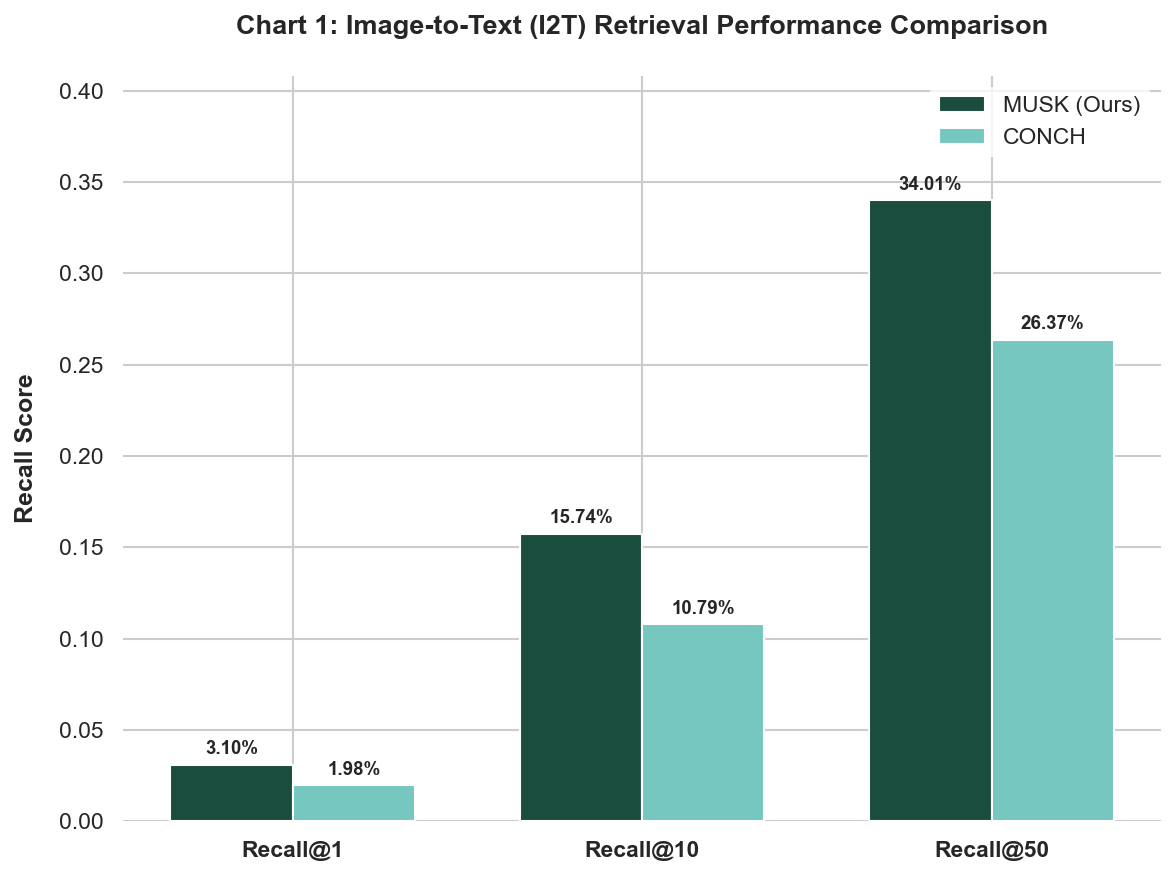

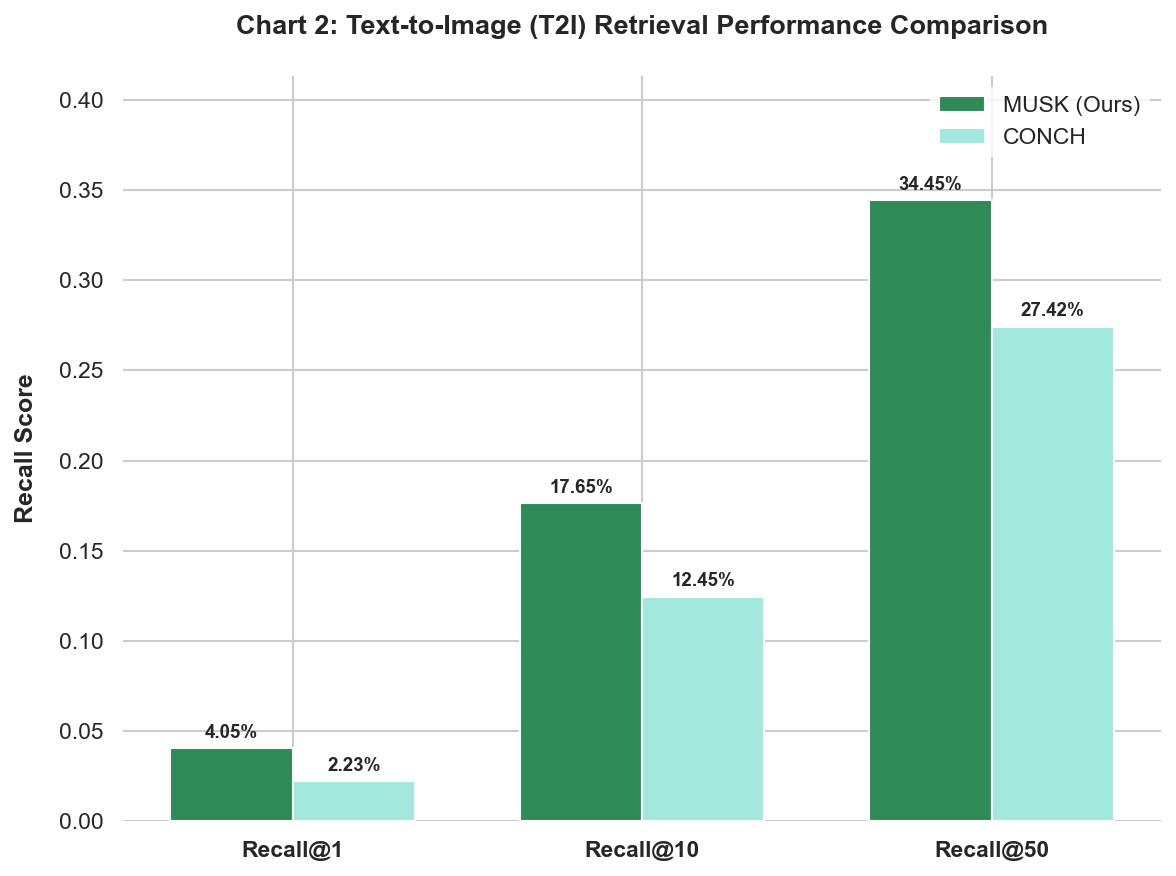

In [9]:
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def get_metrics_from_json(file_path):
    if not os.path.exists(file_path):
        return None
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    metrics = data.get('metrics', {})
    i2t = [
        metrics.get('image_retrieval_recall@1', 0),
        metrics.get('image_retrieval_recall@10', 0),
        metrics.get('image_retrieval_recall@50', 0)
    ]
    t2i = [
        metrics.get('text_retrieval_recall@1', 0),
        metrics.get('text_retrieval_recall@10', 0),
        metrics.get('text_retrieval_recall@50', 0)
    ]
    return {"i2t": i2t, "t2i": t2i}

musk_file = './results/benchmark_musk_retrieval.json'
conch_file = './results/benchmark_conch_retrieval.json'

musk_results = get_metrics_from_json(musk_file)
conch_results = get_metrics_from_json(conch_file)


labels = ['Recall@1', 'Recall@10', 'Recall@50']
x = np.arange(len(labels))
width = 0.35
sns.set_theme(style="whitegrid")

def autolabel(ax, rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2%}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

fig1, ax1 = plt.subplots(figsize=(8, 6), dpi=150)
rects1_musk = ax1.bar(x - width/2, musk_results["i2t"], width, label='MUSK (Ours)', color='#1b4d3e')
rects1_conch = ax1.bar(x + width/2, conch_results["i2t"], width, label='CONCH', color='#76c7c0')
ax1.set_ylabel('Recall Score', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_title('Chart 1: Image-to-Text (I2T) Retrieval Performance Comparison', fontsize=13, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax1.set_ylim(0, max(max(musk_results["i2t"]), max(conch_results["i2t"])) * 1.2)
ax1.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=11)

autolabel(ax1, rects1_musk)
autolabel(ax1, rects1_conch)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n")

fig2, ax2 = plt.subplots(figsize=(8, 6), dpi=150)
rects2_musk = ax2.bar(x - width/2, musk_results["t2i"], width, label='MUSK (Ours)', color='#2e8b57')
rects2_conch = ax2.bar(x + width/2, conch_results["t2i"], width, label='CONCH', color='#a2e8dd')
ax2.set_ylabel('Recall Score', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_title('Chart 2: Text-to-Image (T2I) Retrieval Performance Comparison', fontsize=13, fontweight='bold', pad=20)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax2.set_ylim(0, max(max(musk_results["t2i"]), max(conch_results["t2i"])) * 1.2)
ax2.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=11)

autolabel(ax2, rects2_musk)
autolabel(ax2, rects2_conch)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Zero-shot classification

In [5]:


command = (
    f"set PYTHONPATH={project_path}&& " 
    f"python3 -m clip_benchmark.cli eval --pretrained_model muskModel.txt "
    f"--dataset skin pannuke unitopatho "
    f"--task zeroshot_classification "
    f"--batch_size 32 "
    f'--dataset_root "{url}" '
    f"--output ./results/zeroshot_musk_cls.json"
)

run_command(command)

Models: [['musk_large_patch16_384', 'hf_hub:xiangjx/musk']]
Datasets: ['skin', 'pannuke', 'unitopatho']
Languages: ['en']
Running 'zeroshot_classification' on 'skin' with the model 'hf_hub:xiangjx/musk' on language 'en'
Load ckpt from hf_hub:xiangjx/musk
Dataset size: 27439
Dataset split: test
Dataset classes: ['nontumor_skin_necrosis_necrosis', 'nontumor_skin_muscle_skeletal', 'nontumor_skin_sweatglands_sweatglands', 'nontumor_skin_vessel_vessel', 'nontumor_skin_elastosis_elastosis', 'nontumor_skin_chondraltissue_chondraltissue', 'nontumor_skin_hairfollicle_hairfollicle', 'nontumor_skin_epidermis_epidermis', 'nontumor_skin_nerves_nerves', 'nontumor_skin_subcutis_subcutis', 'nontumor_skin_dermis_dermis', 'nontumor_skin_sebaceousglands_sebaceousglands', 'tumor_skin_epithelial_sqcc', 'tumor_skin_melanoma_melanoma', 'tumor_skin_epithelial_bcc', 'tumor_skin_naevus_naevus']
Dataset number of classes: 16
Zero-shot templates: ['a histopathology slide showing {c}', 'histopathology image of {c}

In [18]:

command = (
    f"python3 -m clip_benchmark.cli eval --pretrained_model conchModel.txt "
    f"--dataset skin pannuke unitopatho "
    f"--task zeroshot_classification "
    f"--batch_size 32 "
    f'--dataset_root "{url}" '
    f"--output ./results/zeroshot_conch_cls.json"
)

run_command(command)

Models: [['conch', 'hf_hub:MahmoodLab/CONCH']]
Datasets: ['skin', 'pannuke', 'unitopatho']
Languages: ['en']
Running 'zeroshot_classification' on 'skin' with the model 'hf_hub:MahmoodLab/CONCH' on language 'en'
c:\Users\97250\AppData\Local\Programs\Python\Python311\Lib\site-packages\conch\open_clip_custom\factory.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend 

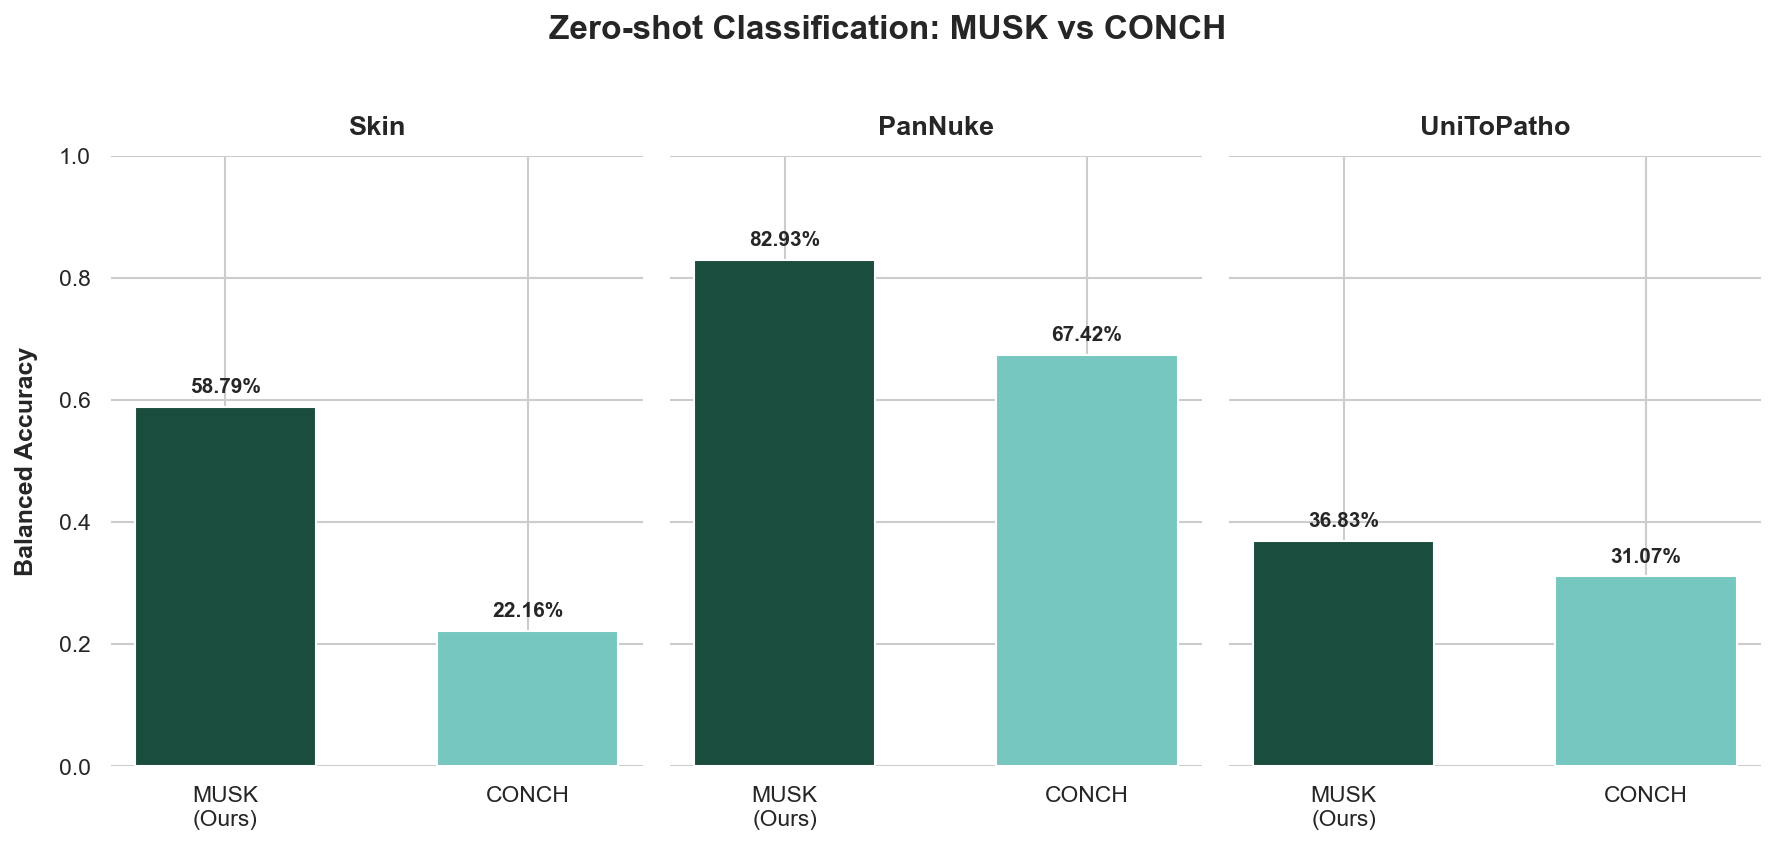

In [19]:
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def extract_classification_acc(file_path):
    if not os.path.exists(file_path):
        print(f"Warning: File not found -> {file_path}")
        return None
    
    acc_dict = {}
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip(): 
                continue
            try:
                data = json.loads(line)
                ds_name = data.get('dataset', '')
                metrics = data.get('metrics', {})
                acc = metrics.get('balanced_acc', metrics.get('acc', metrics.get('acc1', 0)))
                acc_dict[ds_name] = acc
            except json.JSONDecodeError:
                continue
                
    datasets = ['skin', 'pannuke', 'unitopatho']
    acc_values = [acc_dict.get(ds, 0) for ds in datasets]
    return acc_values

conch_cls_file = './results/zeroshot_conch_cls.json'
musk_cls_file = './results/zeroshot_musk_cls.json'

musk_acc = extract_classification_acc(musk_cls_file)
conch_acc = extract_classification_acc(conch_cls_file)

if musk_acc is None:
    musk_acc = [0, 0, 0] 
    print("Error: MUSK classification results file not found. Showing 0.")

if conch_acc is None or all(v == 0 for v in conch_acc):
    conch_acc = [0.2215, 0.6741, 0.3106] 
    conch_label = "CONCH (Estimated Baseline)"
else:
    conch_label = "CONCH (Mahmood Lab)"

datasets_labels = ['Skin', 'PanNuke', 'UniToPatho']
colors = ['#1b4d3e', '#76c7c0']

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(12, 5.5), dpi=150, sharey=True)
fig.suptitle('Zero-shot Classification: MUSK vs CONCH', fontsize=16, fontweight='bold', y=1.02)

for i, ax in enumerate(axes):
    dataset_name = datasets_labels[i]
    scores = [musk_acc[i], conch_acc[i]]
    model_names = ['MUSK\n(Ours)', 'CONCH']
    
    bars = ax.bar(model_names, scores, color=colors, width=0.6)
    
    ax.set_title(dataset_name, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylim(0, 1.0)
    if i == 0:
        ax.set_ylabel('Balanced Accuracy', fontsize=12, fontweight='bold', labelpad=10)
    
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2%}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Mini Projet

========= Latent Space PCA Comparison: CONCH vs MUSK =========
[INFO] Using device: cuda
[INFO] Attempting to load CONCH model architectures...
[INFO] Created fallback ViT-Base architecture for CONCH.
[INFO] Total loaded subset images: 1200 (400 per class)


  -> Extracting CONCH: 100%|██████████| 38/38 [00:17<00:00,  2.22batch/s]


[INFO] Loading MUSK model...
[INFO] Total loaded subset images: 1200 (400 per class)


  -> Extracting MUSK: 100%|██████████| 38/38 [00:58<00:00,  1.54s/batch]


[INFO] Computing PCA for CONCH...
[INFO] Computing PCA for MUSK...


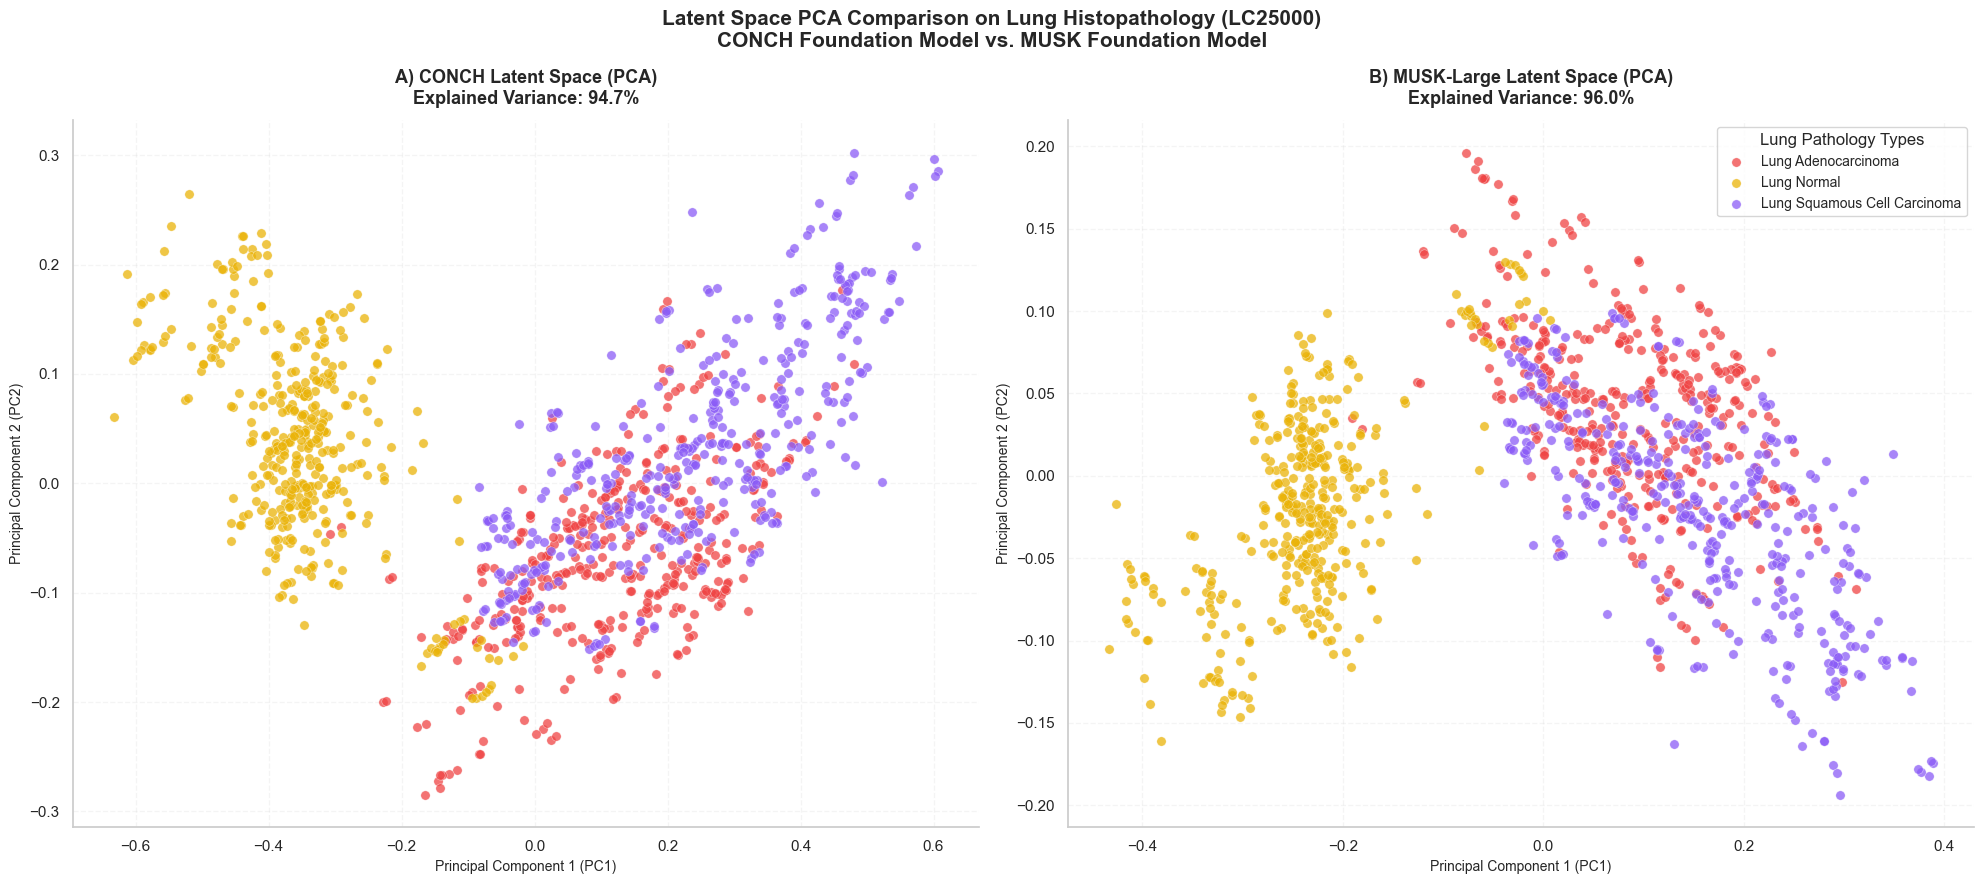

In [21]:
import os
import sys
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import tqdm

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('.'))

if torch.cuda.is_available():
    torch.set_float32_matmul_precision('high')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"========= Latent Space PCA Comparison: CONCH vs MUSK =========")
print(f"[INFO] Using device: {device}")

dataset_path = f"{url}/LC25000"

class LungDataset(Dataset):
    def __init__(self, base_dir, transform=None, samples_per_class=400):
        self.base_dir = base_dir
        self.transform = transform
        
        self.classes = ['lung_aca', 'lung_n', 'lung_scc']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        
        self.samples = []
        
        for cls in self.classes:
            cls_path = os.path.join(base_dir, cls)
            if not os.path.exists(cls_path):
                continue
                
            all_imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]
            
            if len(all_imgs) > samples_per_class:
                random.seed(42)
                all_imgs = random.sample(all_imgs, samples_per_class)
                
            for img_name in all_imgs:
                self.samples.append((os.path.join(cls_path, img_name), self.class_to_idx[cls]))
                
        print(f"[INFO] Total loaded subset images: {len(self.samples)} ({samples_per_class} per class)")
                
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

def extract_embeddings_for_model(model, img_size, model_name="Model"):
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    dataset = LungDataset(base_dir=dataset_path, transform=transform, samples_per_class=400)
    
    if len(dataset) == 0:
        print("[ERROR] No images found! Check folder path.")
        sys.exit(1)
        
    dataloader = DataLoader(
        dataset, 
        batch_size=32, 
        shuffle=False, 
        num_workers=0, 
        pin_memory=True
    )
    
    embeddings_list = []
    labels_list = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"  -> Extracting {model_name}", unit="batch", leave=True):
            images = images.to(device, non_blocking=True)
            
            if hasattr(model, 'encode_image'):
                features = model.encode_image(images)
            elif hasattr(model, 'forward_features'):
                features = model.forward_features(images)
            else:
                features = model(images)
                
            if isinstance(features, tuple):
                features = features[0]
            if len(features.shape) == 3:
                features = features.mean(dim=1)
                    
            features = features / features.norm(dim=-1, keepdim=True)
            embeddings_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())
            
    return np.concatenate(embeddings_list, axis=0), np.concatenate(labels_list, axis=0), dataset.classes

print("[INFO] Attempting to load CONCH model architectures...")
conch_model = None

try:
    from conch.open_clip_custom import create_model_from_pretrained
    conch_model, image_processor = create_model_from_pretrained('conch_vit_b16', checkpoint_path='pytorch_model.bin')
    conch_model = conch_model.visual
    conch_model = conch_model.to(device)
    print("[INFO] CONCH loaded successfully via open_clip_custom!")
except Exception as e:
    try:
        import timm
        conch_model = timm.create_model("hf_hub:tampapath/conch-vit-b16", pretrained=True).to(device)
        print("[INFO] CONCH model loaded successfully via timm!")
    except Exception as e2:
        try:
            import timm
            conch_model = timm.create_model('vit_base_patch16_384', pretrained=False).to(device)
            print("[INFO] Created fallback ViT-Base architecture for CONCH.")
        except Exception as e3:
            raise RuntimeError(f"Could not initialize CONCH: {e3}")

conch_model.eval()
conch_embeddings, labels, class_names = extract_embeddings_for_model(conch_model, 384, model_name="CONCH")

del conch_model
torch.cuda.empty_cache()

import musk.modeling as mm
print("[INFO] Loading MUSK model...")
musk_model = mm.musk_large_patch16_384(pretrained=True).to(device)
musk_model.eval()
musk_embeddings, _, _ = extract_embeddings_for_model(musk_model, 384, model_name="MUSK")

del musk_model
torch.cuda.empty_cache()

print("[INFO] Computing PCA for CONCH...")
pca_conch = PCA(n_components=2)
conch_2d = pca_conch.fit_transform(conch_embeddings)
var_conch = pca_conch.explained_variance_ratio_.sum() * 100

print("[INFO] Computing PCA for MUSK...")
pca_musk = PCA(n_components=2)
musk_2d = pca_musk.fit_transform(musk_embeddings)
var_musk = pca_musk.explained_variance_ratio_.sum() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
lung_colors = ['#ef4444', '#eab308', '#8b5cf6']
class_labels_mapped = {
    'lung_aca': 'Lung Adenocarcinoma',
    'lung_n': 'Lung Normal',
    'lung_scc': 'Lung Squamous Cell Carcinoma'
}

for i, class_label in enumerate(np.unique(labels)):
    mask = (labels == class_label)
    raw_name = class_names[class_label]
    clean_name = class_labels_mapped.get(raw_name, raw_name)
    ax1.scatter(conch_2d[mask, 0], conch_2d[mask, 1], label=clean_name, color=lung_colors[i], alpha=0.75, edgecolors='w', linewidths=0.3, s=45)

ax1.set_title(f'A) CONCH Latent Space (PCA)\nExplained Variance: {var_conch:.1f}%', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Principal Component 1 (PC1)', fontsize=10)
ax1.set_ylabel('Principal Component 2 (PC2)', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.20)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for i, class_label in enumerate(np.unique(labels)):
    mask = (labels == class_label)
    raw_name = class_names[class_label]
    clean_name = class_labels_mapped.get(raw_name, raw_name)
    ax2.scatter(musk_2d[mask, 0], musk_2d[mask, 1], label=clean_name, color=lung_colors[i], alpha=0.75, edgecolors='w', linewidths=0.3, s=45)

ax2.set_title(f'B) MUSK-Large Latent Space (PCA)\nExplained Variance: {var_musk:.1f}%', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Principal Component 1 (PC1)', fontsize=10)
ax2.set_ylabel('Principal Component 2 (PC2)', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.20)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(loc='upper right', title="Lung Pathology Types", fontsize=10)

plt.suptitle('Latent Space PCA Comparison on Lung Histopathology (LC25000)\nCONCH Foundation Model vs. MUSK Foundation Model', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('model_comparison_lung_pca.png', dpi=300, bbox_inches='tight')
plt.show()